In [1]:
import pandas as pd
import argparse
import os
os.chdir('../scripts')
import multiprocessing
import numpy as np
import random
import json
from tqdm import tqdm
from astropy.table import Table
from analysis_tools_cython import *
from scipy.stats import skewnorm

In [2]:
def transit_model(x, A, t0, sigma=0.332715600, alpha=1.43857307e+00):
    """
    Injecting lightcurve using skewed Gaussian function. The default is the Beta Pic parameters.

    Parameters:
        flux: the lightcurve flux
        x: Input data points.
        A: Amplitude of the Gaussian.
        t0: injected time
        sigma: Standard deviation of the Gaussian. # find the Beta Pic
        alpha: Skewness parameter (find the one for Beta Pic)

    Returns:
        y: The value of the skewed Gaussian at each input data point x.

    Notes: These are the Beta Pic parameters:
        - A = 8.84860547e-04, t0 = 1.48614591e+03, sigma = 3.28541476e-01, alpha = 1.43857307e+00
    """

   

    return (A * skewnorm.pdf(x,alpha,loc=t0, scale=sigma))


In [3]:
metadata = pd.read_csv('../metadata-combined.txt')

In [4]:
metadata.head()

,filepath,TIC_ID,Sector,Camera,Chip,RA,DEC,GAIAmag,gaiabp,gaiarp,...,e_plx,Tmag,e_Tmag,Bmag,e_Bmag,Vmag,lum,lumclass,Teff,filepath2
0,hlsp_gsfc-eleanor-lite_tess_ffi_s0012-00000003...,306572816,12,4,2,119.063089,-70.17641,11.6018,12.2007,10.8875,...,0.018885,10.9324,0.006,12.999,0.015,11.882,0.057,GIANT,4802.8,/storage/astro2/phrdhx/eleanor-lite-project-v2...
1,hlsp_gsfc-eleanor-lite_tess_ffi_s0004-00000003...,306572816,4,4,4,119.063089,-70.17641,11.6018,12.2007,10.8875,...,0.018885,10.9324,0.006,12.999,0.015,11.882,0.057,GIANT,4802.8,/storage/astro2/phrdhx/eleanor-lite-project-v2...
2,hlsp_gsfc-eleanor-lite_tess_ffi_s0003-00000003...,306572816,3,4,3,119.063089,-70.17641,11.6018,12.2007,10.8875,...,0.018885,10.9324,0.006,12.999,0.015,11.882,0.057,GIANT,4802.8,/storage/astro2/phrdhx/eleanor-lite-project-v2...
3,hlsp_gsfc-eleanor-lite_tess_ffi_s0013-00000003...,306572816,13,4,2,119.063089,-70.17641,11.6018,12.2007,10.8875,...,0.018885,10.9324,0.006,12.999,0.015,11.882,0.057,GIANT,4802.8,/storage/astro2/phrdhx/eleanor-lite-project-v2...
4,hlsp_gsfc-eleanor-lite_tess_ffi_s0002-00000003...,306572816,2,4,3,119.063089,-70.17641,11.6018,12.2007,10.8875,...,0.018885,10.9324,0.006,12.999,0.015,11.882,0.057,GIANT,4802.8,/storage/astro2/phrdhx/eleanor-lite-project-v2...


In [5]:
metadata.filepath2.sample(1).values

array(['/storage/astro2/phrdhx/eleanor-lite-project-v2/s0012/hlsp_gsfc-eleanor-lite_tess_ffi_s0012-0000000463887603_tess_v1.0_lc.fits'],
      dtype=object)

In [6]:
lc, lc_info = import_lightcurve('/storage/astro2/phrdhx/eleanor-lite-project-v2/s0007/hlsp_gsfc-eleanor-lite_tess_ffi_s0007-0000000270577175_tess_v1.0_lc.fits')

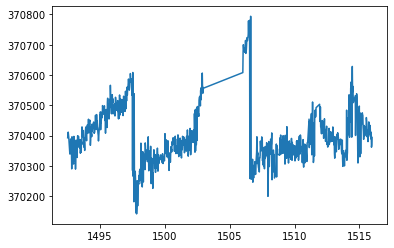

In [7]:
plt.plot(lc['TIME'],lc['PCA_FLUX'])

In [8]:
lc = lc.to_pandas()

In [9]:
depth = 10 ** np.random.uniform(-2, -1, 1)[0] 
time_range = lc["TIME"][
        lc["TIME"].between(
            lc["TIME"].min() + 1, lc["TIME"].max() - 1, inclusive=False
        )
    ].reset_index(
        drop=True
    )
_, injected_time = random.choice(list(enumerate(time_range)))
alpha_rand = random.uniform(0, 8)

In [10]:
print(depth)
print(injected_time)

0.048226313931063705
1511.4078530674622


In [427]:
depth = 0.0001
sigma = 0.5
injected_flux = 1 - transit_model(lc['TIME'],  depth,1510,sigma=0.3,alpha=2)
injected_flux2 = 1 - transit_model(lc['TIME'], depth,1510,sigma=,alpha=2)

# Injecting into lightcurve
lc['FLUX'] = lc['PCA_FLUX'] * injected_flux
lc['FLUX2'] = lc['PCA_FLUX'] * injected_flux2

(0.995, 1.002)

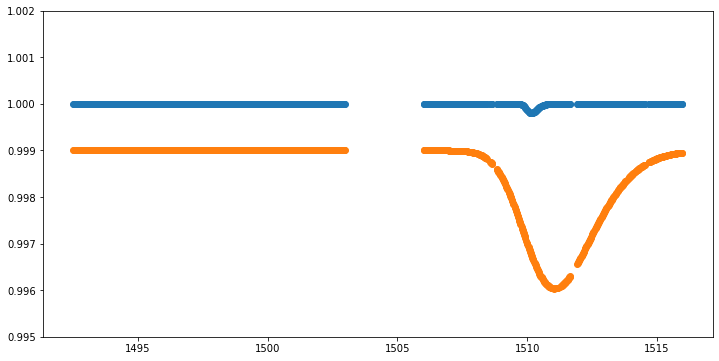

In [428]:
plt.figure(figsize=(12,6))
plt.scatter(lc['TIME'],injected_flux)
plt.scatter(lc['TIME'],injected_flux2-0.001)
plt.ylim([0.995,1.002])


---

### Comet model

In [418]:
def inject_comet(flux, time, depth, injected_time):
    return flux * (
        1 - comet_curve(time, depth, injected_time, 0.5, 3.40346173e-01)
    )

In [419]:
#depth = 10 ** np.random.uniform(-4, -2)
new_flux = inject_comet(lc["PCA_FLUX"], lc["TIME"], depth, 1510)

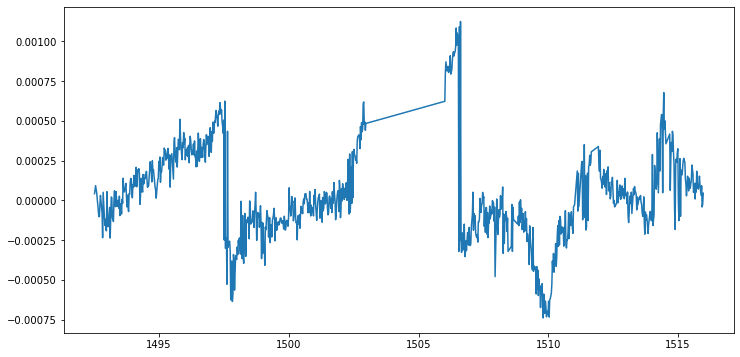

In [420]:
plt.figure(figsize=(12,6))
plt.plot(lc["TIME"], normalise_flux(new_flux))